In [45]:
import pandas as pd
import numpy as np                         
import matplotlib.pyplot as plt           
import seaborn as sns 

In [46]:
from sklearn.preprocessing import StandardScaler    # Scales features to mean=0, std=1
from sklearn.model_selection import (
    train_test_split,                     
    cross_val_score,                      
    StratifiedKFold,                       
    GridSearchCV,                          
    RandomizedSearchCV                     
)

Data Loading

In [47]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
cardiotocography = fetch_ucirepo(id=193) 
  
# data (as pandas dataframes) 
X = cardiotocography.data.features 
y = cardiotocography.data.targets 
  
# metadata 
print(cardiotocography.metadata) 
  
# variable information 
print(cardiotocography.variables) 

{'uci_id': 193, 'name': 'Cardiotocography', 'repository_url': 'https://archive.ics.uci.edu/dataset/193/cardiotocography', 'data_url': 'https://archive.ics.uci.edu/static/public/193/data.csv', 'abstract': 'The dataset consists of measurements of fetal heart rate (FHR) and uterine contraction (UC) features on cardiotocograms classified by expert obstetricians.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 2126, 'num_features': 21, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['CLASS', 'NSP'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2000, 'last_updated': 'Fri Mar 15 2024', 'dataset_doi': '10.24432/C51S4N', 'creators': ['D. Campos', 'J. Bernardes'], 'intro_paper': None, 'additional_info': {'summary': '2126 fetal cardiotocograms (CTGs) were automatically processed and the respective diagnostic features measured. The CTGs were also classified

In [48]:
df = pd.concat([X, y], axis=1)
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,...,Max,Nmax,Nzeros,Mode,Mean,Median,Variance,Tendency,CLASS,NSP
0,120,0.000,0.0,0.000,0.000,0.0,0.0,73,0.5,43,...,126,2,0,120,137,121,73,1,9,2
1,132,0.006,0.0,0.006,0.003,0.0,0.0,17,2.1,0,...,198,6,1,141,136,140,12,0,6,1
2,133,0.003,0.0,0.008,0.003,0.0,0.0,16,2.1,0,...,198,5,1,141,135,138,13,0,6,1
3,134,0.003,0.0,0.008,0.003,0.0,0.0,16,2.4,0,...,170,11,0,137,134,137,13,1,6,1
4,132,0.007,0.0,0.008,0.000,0.0,0.0,16,2.4,0,...,170,9,0,137,136,138,11,1,2,1


In [49]:
df.shape

(2126, 23)

In [50]:
df.columns.tolist()

['LB',
 'AC',
 'FM',
 'UC',
 'DL',
 'DS',
 'DP',
 'ASTV',
 'MSTV',
 'ALTV',
 'MLTV',
 'Width',
 'Min',
 'Max',
 'Nmax',
 'Nzeros',
 'Mode',
 'Mean',
 'Median',
 'Variance',
 'Tendency',
 'CLASS',
 'NSP']

Data Preprocessing

In [51]:
feature_cols = [
    'LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP',
    'ASTV', 'MSTV', 'ALTV', 'MLTV',
    'Width', 'Min', 'Max', 'Nmax', 'Nzeros',
    'Mode', 'Mean', 'Median', 'Variance', 'Tendency'
]
target_col = 'NSP'

# Keep only relevant columns
df = df[feature_cols + [target_col]].copy()

In [ ]:
#Handle Missing Values
print(f"Missing values before cleaning:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.dropna(inplace=True)                    # Drop any rows with missing values
print(f"\nDataset shape after cleaning: {df.shape}")

Missing values before cleaning:
Series([], dtype: int64)

Dataset shape after cleaning: (2126, 22)


In [53]:
# Separate features and target
X = df[feature_cols]                       # All 21 input features
y = df[target_col].astype(int)             # Target class labels (1, 2, or 3)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")


Feature matrix shape: (2126, 21)
Target distribution:
NSP
1    1655
2     295
3     176
Name: count, dtype: int64


EDA

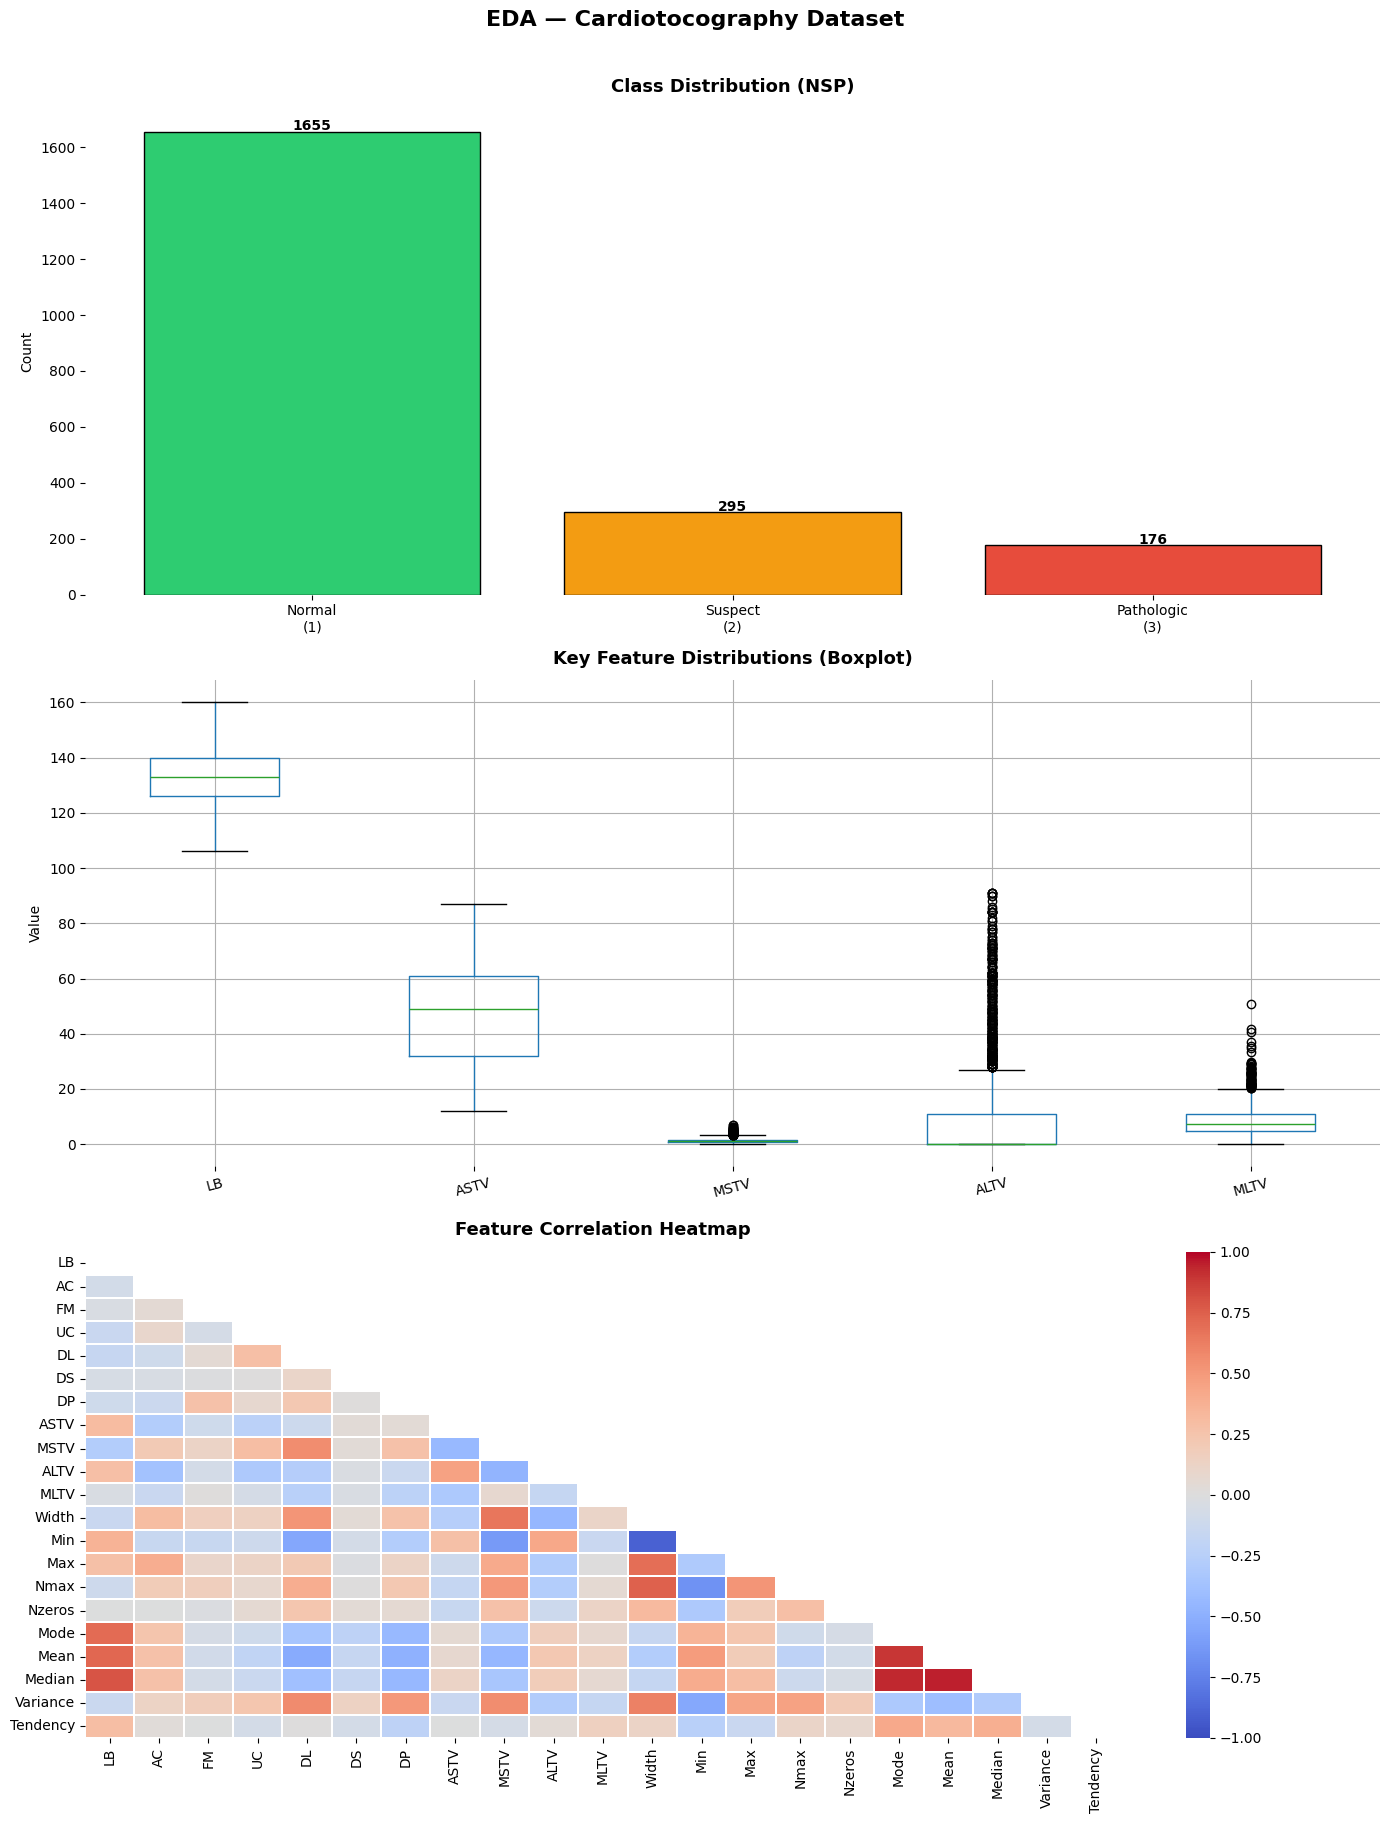

In [57]:
fig = plt.figure(figsize=(14, 18))
fig.suptitle('EDA — Cardiotocography Dataset', fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Class Distribution ─────────────────────────────────────────────────
ax1 = fig.add_subplot(3, 1, 1)
class_counts = y.value_counts().sort_index()
ax1.bar(['Normal\n(1)', 'Suspect\n(2)', 'Pathologic\n(3)'],
        class_counts.values,
        color=['#2ecc71', '#f39c12', '#e74c3c'],
        edgecolor='black')
ax1.set_title('Class Distribution (NSP)', fontsize=13, fontweight='bold', pad=12)
ax1.set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    ax1.text(i, v + 5, str(v), ha='center', fontweight='bold')
for spine in ax1.spines.values():
    spine.set_visible(False)

# ── Plot 2: Feature Boxplot ────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 1, 2)
key_features = ['LB', 'ASTV', 'MSTV', 'ALTV', 'MLTV']
X[key_features].boxplot(ax=ax2)
ax2.set_title('Key Feature Distributions (Boxplot)', fontsize=13, fontweight='bold', pad=12)
ax2.set_xticklabels(key_features, rotation=15)
ax2.set_ylabel('Value')
for spine in ax2.spines.values():
    spine.set_visible(False)

# ── Plot 3: Correlation Heatmap ────────────────────────────────────────────────
ax3 = fig.add_subplot(3, 1, 3)
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax3, mask=mask, cmap='coolwarm',
            annot=False, fmt='.1f', linewidths=0.3, vmin=-1, vmax=1)
ax3.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=12)
for spine in ax3.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

Standard Scalling and Train-Test Split

In [61]:
#Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)        # Fit and transform all features
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

print(f"Mean of first feature after scaling: {X_scaled['LB'].mean():.4f}  (should be ~0)")
print(f"Std  of first feature after scaling: {X_scaled['LB'].std():.4f}   (should be ~1)")

Mean of first feature after scaling: 0.0000  (should be ~0)
Std  of first feature after scaling: 1.0002   (should be ~1)


In [63]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,                              
    y,                                     
    test_size=0.20,                        
    stratify=y,                            
    random_state=42                        
)

print(f"Training set size : {X_train.shape[0]} samples")
print(f"Testing  set size : {X_test.shape[0]} samples")
print(f"\nTrain class distribution:\n{y_train.value_counts().sort_index()}")
print(f"\nTest class distribution:\n{y_test.value_counts().sort_index()}")

Training set size : 1700 samples
Testing  set size : 426 samples

Train class distribution:
NSP
1    1323
2     236
3     141
Name: count, dtype: int64

Test class distribution:
NSP
1    332
2     59
3     35
Name: count, dtype: int64


Model Training

In [88]:
from sklearn.linear_model import LogisticRegression          
from sklearn.ensemble import RandomForestClassifier          
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,                 
    confusion_matrix,                      
    accuracy_score                         
)
import json

In [86]:
# Model 1: Logistic Regression 
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)             # Train on training data
print("Model 1: Logistic Regression — trained")

# Model 2: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("Model 2: Random Forest Classifier — trained")

# Model 3: Support Vector Machine
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)
print("Model 3: Support Vector Machine (RBF Kernel) — trained")

# Store all models in a dictionary for easy iteration
models = {
    'Logistic Regression': lr_model,
    'Random Forest':       rf_model,
    'SVM (RBF)':           svm_model
}

Model 1: Logistic Regression — trained
Model 2: Random Forest Classifier — trained
Model 3: Support Vector Machine (RBF Kernel) — trained


Model Evaluation

In [85]:
all_results = {}   # Stores classification reports for all models

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f" {name}")
    print(f"{'='*55}")

    #  Step 1: Predict on the held-out test set 
    y_pred = model.predict(X_test)

    #  Step 2: Accuracy Score 
    acc = accuracy_score(y_test, y_pred)
    print(f"  Accuracy : {acc:.4f} ({acc*100:.2f}%)")

    #  Step 3: Full Classification Report
    report_dict = classification_report(
        y_test, y_pred,
        target_names=['Normal', 'Suspect', 'Pathologic'],
        output_dict=True
    )
    report_str = classification_report(
        y_test, y_pred,
        target_names=['Normal', 'Suspect', 'Pathologic']
    )
    print(f"\n{report_str}")
    all_results[name] = report_dict         # Save report

# Save combined classification report to JSON (as required)
with open('classification_report.json', 'w') as f:
    json.dump(all_results, f, indent=4)
print("\n Classification report saved → classification_report.json")


 Logistic Regression
  Accuracy : 0.8850 (88.50%)

              precision    recall  f1-score   support

      Normal       0.94      0.95      0.94       332
     Suspect       0.61      0.68      0.64        59
  Pathologic       0.88      0.66      0.75        35

    accuracy                           0.88       426
   macro avg       0.81      0.76      0.78       426
weighted avg       0.89      0.88      0.89       426


 Random Forest
  Accuracy : 0.9272 (92.72%)

              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       332
     Suspect       0.85      0.68      0.75        59
  Pathologic       0.86      0.86      0.86        35

    accuracy                           0.93       426
   macro avg       0.88      0.84      0.86       426
weighted avg       0.92      0.93      0.92       426


 SVM (RBF)
  Accuracy : 0.8944 (89.44%)

              precision    recall  f1-score   support

      Normal       0.93      0.97      0.95

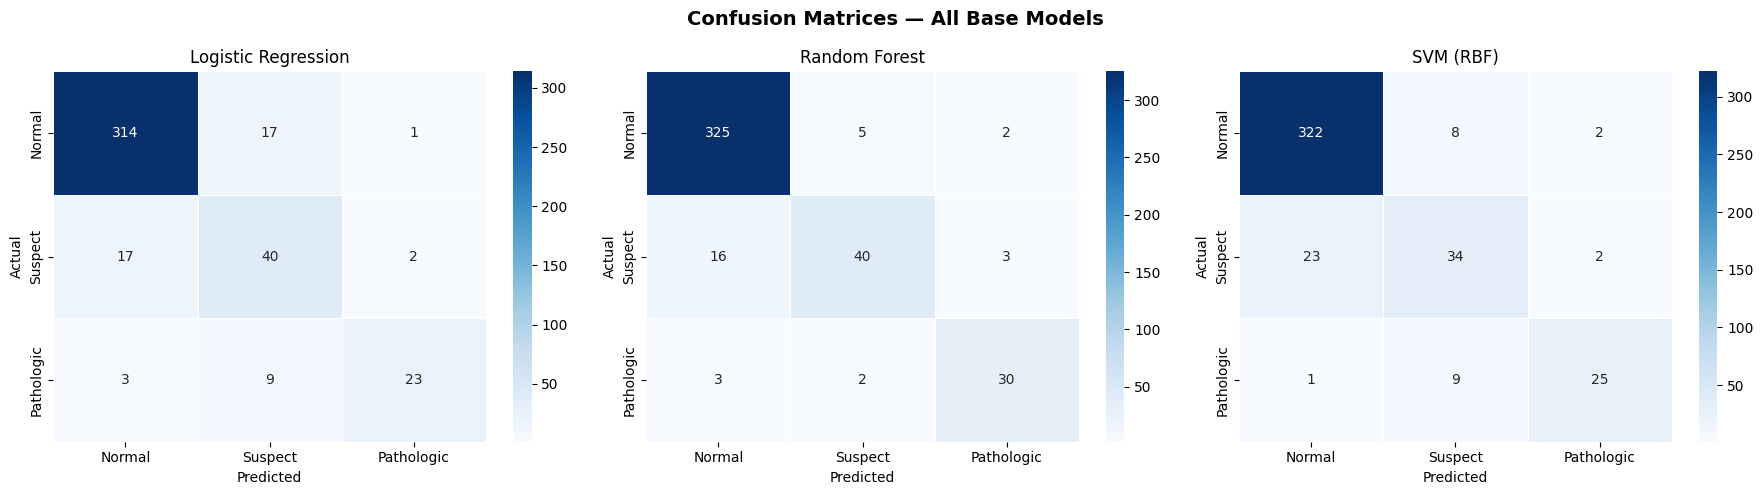

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices — All Base Models', fontsize=14, fontweight='bold')
class_labels = ['Normal', 'Suspect', 'Pathologic']

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_labels, yticklabels=class_labels,
        ax=ax, linewidths=0.5
    )
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [73]:
# Stratified K-Fold object
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    # Standard K-Fold CV (accuracy metric)
    kf_scores = cross_val_score(
        model, X_scaled, y, cv=10, scoring='accuracy'
    )

    # Stratified K-Fold CV (accuracy metric)
    skf_scores = cross_val_score(
        model, X_scaled, y, cv=skf, scoring='accuracy'
    )

    print(f"\n  {name}")
    print(f"    K-Fold CV           → Mean: {kf_scores.mean():.4f} | Std: {kf_scores.std():.4f}")
    print(f"    Stratified K-Fold   → Mean: {skf_scores.mean():.4f} | Std: {skf_scores.std():.4f}")
    # Lower std means more stable/consistent model across different data splits


  Logistic Regression
    K-Fold CV           → Mean: 0.8612 | Std: 0.0859
    Stratified K-Fold   → Mean: 0.8965 | Std: 0.0205

  Random Forest
    K-Fold CV           → Mean: 0.8795 | Std: 0.0657
    Stratified K-Fold   → Mean: 0.9450 | Std: 0.0119

  SVM (RBF)
    K-Fold CV           → Mean: 0.8612 | Std: 0.0781
    Stratified K-Fold   → Mean: 0.9101 | Std: 0.0188


Testing New Instances

In [84]:
new_instance = pd.DataFrame([{
    'LB':120, 'AC':0.003, 'FM':0.000, 'UC':0.003,
    'DL':0.001, 'DS':0.000, 'DP':0.000,
    'ASTV':73, 'MSTV':0.5, 'ALTV':43, 'MLTV':2.4,
    'Width':64, 'Min':62,  'Max':126, 'Nmax':4,
    'Nzeros':0, 'Mode':120, 'Mean':137, 'Median':121,
    'Variance':73, 'Tendency':1
}])

new_instance_scaled = scaler.transform(new_instance)

label_map = {1: 'Normal', 2: 'Suspect', 3: 'Pathologic'}

print("🔍 Predictions for New Instance:")
print("-" * 40)
for name, model in models.items():
    pred       = model.predict(new_instance_scaled)[0]
    proba      = model.predict_proba(new_instance_scaled)[0]
    confidence = proba.max() * 100
    print(f"  {name:25s} → {label_map[pred]:10s} (confidence: {confidence:.1f}%)")

#  Batch Prediction (multiple new instances)
batch = X_test.iloc[:5]                    # Take first 5 rows of test set as example batch
batch_preds = rf_model.predict(batch)
print(f"\n Batch Predictions (Random Forest, 5 samples): {[label_map[p] for p in batch_preds]}")
print(f"   Actual labels                               : {[label_map[p] for p in y_test.iloc[:5].values]}")

🔍 Predictions for New Instance:
----------------------------------------
  Logistic Regression       → Suspect    (confidence: 69.8%)
  Random Forest             → Suspect    (confidence: 48.0%)
  SVM (RBF)                 → Suspect    (confidence: 70.6%)

 Batch Predictions (Random Forest, 5 samples): ['Normal', 'Normal', 'Normal', 'Normal', 'Normal']
   Actual labels                               : ['Normal', 'Normal', 'Normal', 'Normal', 'Normal']


c:\Users\DEll\ML-Project\my_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\DEll\ML-Project\my_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\DEll\ML-Project\my_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\DEll\ML-Project\my_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\DEll\ML-Project\my_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names

Model Optimization: Hyperparameter

In [83]:
# HYPERPARAMETER TUNING — RANDOM FOREST (RandomizedSearchCV)

rf_param_dist = {
    'n_estimators':      [50, 100, 200, 300],      
    'max_depth':         [None, 10, 20, 30],       
    'min_samples_split': [2, 5, 10],               
    'min_samples_leaf':  [1, 2, 4],                
    'max_features':      ['sqrt', 'log2']          
}

print("⚙️  Tuning Random Forest with RandomizedSearchCV (this may take ~1 min)...")
rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,                             # Try 20 random combinations
    cv=skf,                                # Stratified 10-fold CV
    scoring='accuracy',
    n_jobs=-1,                             
    random_state=42,
    verbose=0
)
rf_random_search.fit(X_train, y_train)

print(f"\n Best RF Parameters : {rf_random_search.best_params_}")
print(f"   Best CV Accuracy   : {rf_random_search.best_score_:.4f}")

⚙️  Tuning Random Forest with RandomizedSearchCV (this may take ~1 min)...

 Best RF Parameters : {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
   Best CV Accuracy   : 0.9494


In [82]:
# HYPERPARAMETER TUNING — LOGISTIC REGRESSION (GridSearchCV)

lr_param_grid = {
    'C':       [0.01, 0.1, 1.0, 10.0, 100.0], # Inverse of regularization strength
    'solver':  ['lbfgs', 'saga'],              # Optimization algorithm
    'penalty': ['l2']                          # Regularization type
}

print("⚙️  Tuning Logistic Regression with GridSearchCV...")
lr_grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_param_grid,
    cv=skf,                                # Stratified 10-fold CV
    scoring='accuracy',
    n_jobs=-1
)
lr_grid_search.fit(X_train, y_train)

print(f"\n Best LR Parameters : {lr_grid_search.best_params_}")
print(f"   Best CV Accuracy   : {lr_grid_search.best_score_:.4f}")

⚙️  Tuning Logistic Regression with GridSearchCV...


c:\Users\DEll\ML-Project\my_venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



 Best LR Parameters : {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
   Best CV Accuracy   : 0.8941


In [81]:
# EVALUATE TUNED MODELS ON TEST SET

tuned_models = {
    'Tuned Logistic Regression': lr_grid_search.best_estimator_,
    'Tuned Random Forest':        rf_random_search.best_estimator_
}

print("Tuned Model Performance on Test Set")
for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    print(f"\n  {name}")
    print(f"    Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")

#  Demo inference on new instance with tuned model
best_tuned_model = rf_random_search.best_estimator_   # Use tuned RF as our best model
tuned_pred = best_tuned_model.predict(new_instance_scaled)[0]
print(f"\n Tuned RF Prediction on new patient: {label_map[tuned_pred]}")

Tuned Model Performance on Test Set

  Tuned Logistic Regression
    Test Accuracy: 0.8826 (88.26%)

  Tuned Random Forest
    Test Accuracy: 0.9272 (92.72%)

 Tuned RF Prediction on new patient: Suspect


c:\Users\DEll\ML-Project\my_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Model Serialization

In [79]:
import joblib 

In [80]:
best_model_path  = 'rf_best_model.pkl'
scaler_path      = 'scaler.pkl'

joblib.dump(best_tuned_model, best_model_path)   # Save the trained model
joblib.dump(scaler, scaler_path)                 # Save the scaler too (ALWAYS save alongside model)

print(f"Best model saved  → {best_model_path}")
print(f"Scaler saved      → {scaler_path}")

Best model saved  → rf_best_model.pkl
Scaler saved      → scaler.pkl


Loading Save Model

In [90]:
loaded_model  = joblib.load(best_model_path)     # Load trained model
loaded_scaler = joblib.load(scaler_path)         # Load scaler

print("Model and scaler loaded from disk.")
print(f"   Model type: {type(loaded_model).__name__}")

# ── Verify predictions match ───────────────────────────────────────────────────
loaded_pred = loaded_model.predict(
    loaded_scaler.transform(new_instance)        # Scale new data using loaded scaler
)[0]

print(f"\n Loaded model prediction on new instance: {label_map[loaded_pred]}")

# Final accuracy check on test set
y_pred_loaded = loaded_model.predict(X_test)
final_acc     = accuracy_score(y_test, y_pred_loaded)
print(f"\n Final Test Accuracy (loaded model): {final_acc:.4f} ({final_acc*100:.2f}%)")

Model and scaler loaded from disk.
   Model type: RandomForestClassifier

 Loaded model prediction on new instance: Suspect

 Final Test Accuracy (loaded model): 0.9272 (92.72%)


c:\Users\DEll\ML-Project\my_venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
